# Task 1 - Understanding the Model and Data
Trend, stationarity, and volatility analysis of Brent oil prices.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

## 1. Load and prepare data

In [12]:
import os
import sys


df = pd.read_csv(r'C:\Users\Hermela\Desktop\10academy\week 10\data\BrentOilPrices.csv')
def parse_mixed_dates(date_str):
    date_str = str(date_str).strip().strip('"')
    for fmt in ("%d-%b-%y", "%b %d, %Y"):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(date_str)  # fallback: let pandas infer


df["Date"] = df["Date"].apply(parse_mixed_dates)
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.info())
print("Missing values:\n", df.isna().sum())

        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB
None
Missing values:
 Date     0
Price    0
dtype: int64


## 2. Trend analysis - raw price plot

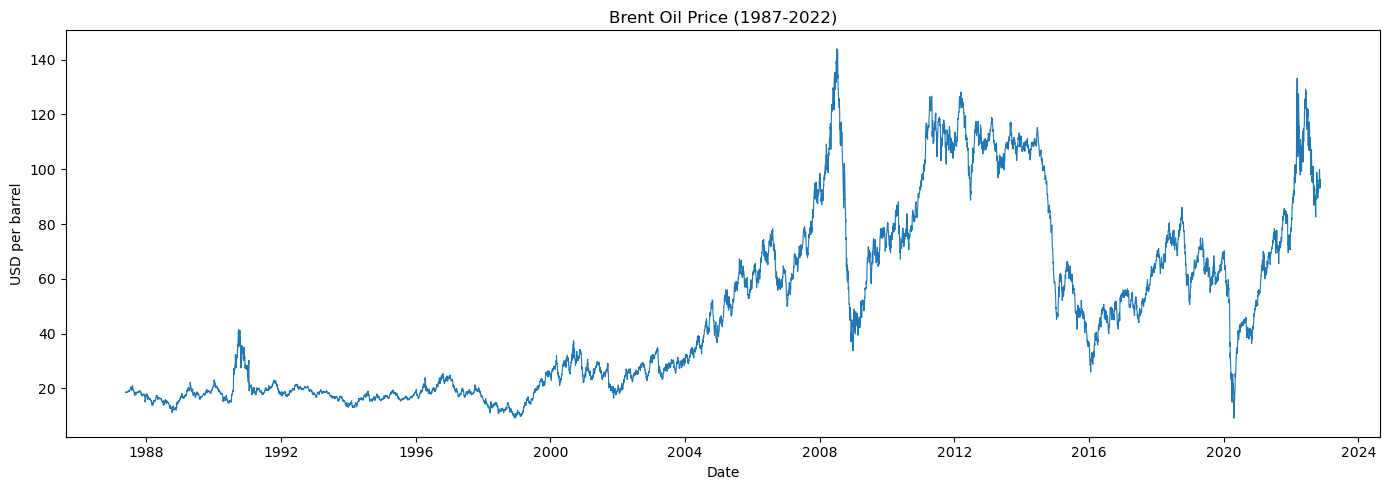

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Price"], linewidth=0.8)
plt.title("Brent Oil Price (1987-2022)")
plt.xlabel("Date")
plt.ylabel("USD per barrel")
plt.tight_layout()

plt.show()

## 3. Log returns - variance-stabilizing transform

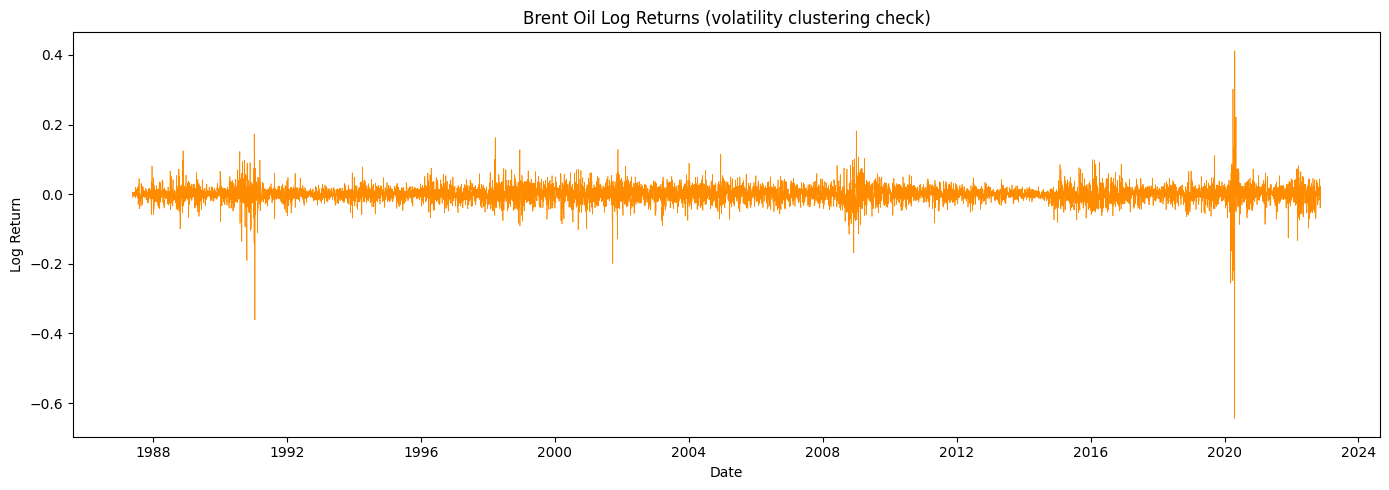

In [ ]:
df["log_price"] = np.log(df["Price"])
df["log_return"] = df["log_price"].diff()
df = df.dropna(subset=["log_return"])

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["log_return"], linewidth=0.5, color="darkorange")
plt.title("Brent Oil Log Returns (volatility clustering check)")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.tight_layout()
plt.savefig("../outputs/log_returns.png", dpi=150)
plt.show()

## 4. Stationarity testing (Augmented Dickey-Fuller)

In [ ]:
def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"\nADF Test - {label}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Critical values: {result[4]}")
    conclusion = "Stationary" if result[1] < 0.05 else "Non-stationary"
    print(f"  Conclusion: {conclusion}")
    return result

adf_price = run_adf(df["Price"], "Raw Price")
adf_return = run_adf(df["log_return"], "Log Returns")


ADF Test - Raw Price
  ADF Statistic: -1.9919
  p-value:       0.2902
  Critical values: {'1%': np.float64(-3.4310784153953295), '5%': np.float64(-2.8618619122481883), '10%': np.float64(-2.566941348864837)}
  Conclusion: Non-stationary



ADF Test - Log Returns
  ADF Statistic: -16.4271
  p-value:       0.0000
  Critical values: {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}
  Conclusion: Stationary


## 5. Volatility patterns - rolling std as a proxy

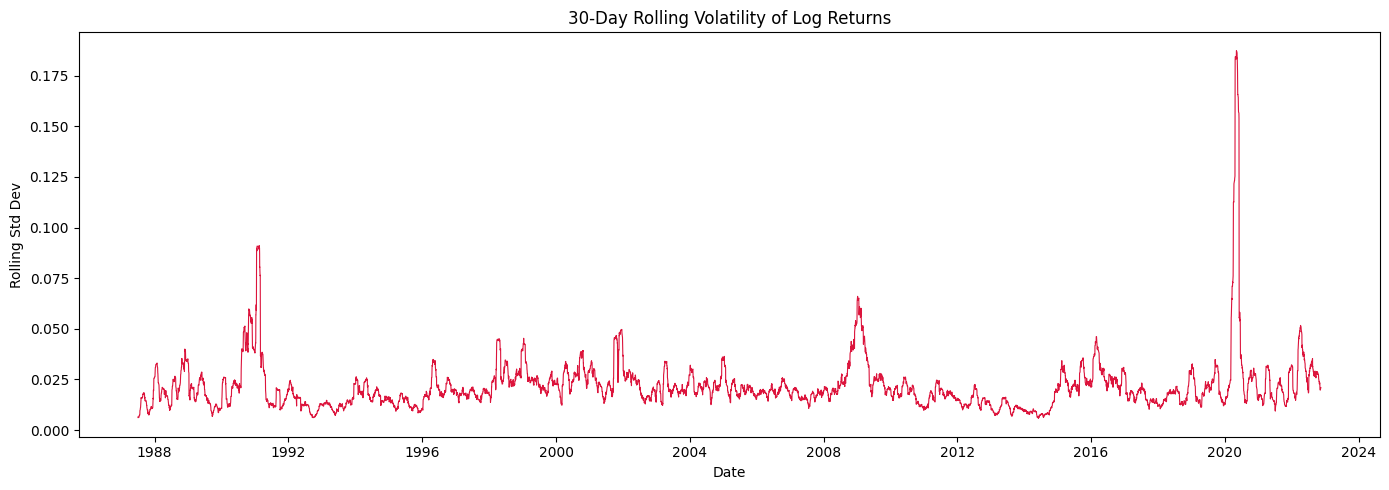

In [ ]:
df["rolling_vol_30d"] = df["log_return"].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["rolling_vol_30d"], linewidth=0.8, color="crimson")
plt.title("30-Day Rolling Volatility of Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev")
plt.tight_layout()
plt.savefig("../outputs/rolling_volatility.png", dpi=150)
plt.show()

## 6. Summary printout for the report

In [ ]:
print("\n--- Summary for report ---")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Raw price ADF p-value: {adf_price[1]:.4f} -> "
      f"{'stationary' if adf_price[1] < 0.05 else 'non-stationary'}")
print(f"Log return ADF p-value: {adf_return[1]:.4f} -> "
      f"{'stationary' if adf_return[1] < 0.05 else 'non-stationary'}")


--- Summary for report ---
Date range: 1987-05-21 to 2022-11-14
Raw price ADF p-value: 0.2902 -> non-stationary
Log return ADF p-value: 0.0000 -> stationary
